# Crypt sizes

Load every graph-based crypt segmentation from the selected datasets, merge timepoint folders by their shared prefix (for example, `day4p5` and `day4p5-more`), and plot distributions of total and LGR5-positive cell counts per crypt.

Marker values are read directly from `graphs_preprocessed/markers_bin`. This notebook does not harmonize markers, apply marker-exclusivity rules, or filter crypts.

In [1]:
import glob
import os
import re
from functools import lru_cache

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from organograph.graph.access import graph_get
from organograph.graph.io import load_cell_graph
from organograph.io_utils.segmentation_io import load_graph_crypt_segmentation

plt.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

## Paths and grouping

The requested `20250112` folder is used when present. In this checkout the corresponding dataset folder is named `20251201`, so it is configured as an explicit fallback rather than silently relabeling those data.

In [2]:
PROJECT_ROOT = os.path.abspath(os.getcwd())
if os.path.basename(PROJECT_ROOT) in {'notebooks', 'notebooks_dev', 'legacy'}:
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)

DATA_ROOT = os.path.abspath(os.path.join(PROJECT_ROOT, '..', 'NicoleData'))
REQUESTED_DATASETS = ['20250929', '20250112']
DATASET_FALLBACKS = {'20250112': '20251201'}
SEG_SUBDIR = 'crypt_segmentations_graph'
GRAPH_SUBDIR = 'graphs_preprocessed'
LGR5_ALIASES = ('LGR5', 'LGR')
N_HISTOGRAM_BINS = 75
EXCLUDE_LARGEST_CRYPT_FRACTION = 0.05
EXCLUDE_LARGEST_LGR5_FRACTION = 0.05


def resolve_dataset_folder(requested_dataset):
    requested_path = os.path.join(DATA_ROOT, requested_dataset)
    if os.path.isdir(requested_path):
        return requested_dataset, requested_path

    fallback = DATASET_FALLBACKS.get(requested_dataset)
    fallback_path = os.path.join(DATA_ROOT, fallback) if fallback else None
    if fallback_path and os.path.isdir(fallback_path):
        print(f'[warn] {requested_dataset} was not found; using dataset folder {fallback}.')
        return fallback, fallback_path

    raise FileNotFoundError(f'Could not find dataset {requested_dataset} below {DATA_ROOT}')


DATASET_SPECS = []
for requested_dataset in REQUESTED_DATASETS:
    dataset, dataset_root = resolve_dataset_folder(requested_dataset)
    DATASET_SPECS.append({
        'requested_dataset': requested_dataset,
        'dataset': dataset,
        'dataset_root': dataset_root,
        'seg_dir': os.path.join(dataset_root, SEG_SUBDIR),
        'graphs_dir': os.path.join(dataset_root, GRAPH_SUBDIR),
    })

DATASET_SPECS

[warn] 20250112 was not found; using dataset folder 20251201.


[{'requested_dataset': '20250929',
  'dataset': '20250929',
  'dataset_root': '/home/fmoller/Projects/LearningOrganoids/NicoleData/20250929',
  'seg_dir': '/home/fmoller/Projects/LearningOrganoids/NicoleData/20250929/crypt_segmentations_graph',
  'graphs_dir': '/home/fmoller/Projects/LearningOrganoids/NicoleData/20250929/graphs_preprocessed'},
 {'requested_dataset': '20250112',
  'dataset': '20251201',
  'dataset_root': '/home/fmoller/Projects/LearningOrganoids/NicoleData/20251201',
  'seg_dir': '/home/fmoller/Projects/LearningOrganoids/NicoleData/20251201/crypt_segmentations_graph',
  'graphs_dir': '/home/fmoller/Projects/LearningOrganoids/NicoleData/20251201/graphs_preprocessed'}]

## Load crypt sizes

The canonical timepoint is the leading `day...` token. Consequently, all folders sharing that prefix are pooled across both datasets. Every saved crypt is retained, including crypts without LGR5-positive cells.

In [3]:
TIMEPOINT_PREFIX_RE = re.compile(r'^(day\d+(?:p\d+)?)', flags=re.IGNORECASE)


def canonical_timepoint(folder_name):
    match = TIMEPOINT_PREFIX_RE.match(str(folder_name))
    return match.group(1).lower() if match else str(folder_name)


def timepoint_sort_key(timepoint):
    match = re.match(r'^day(\d+)(?:p(\d+))?$', str(timepoint), flags=re.IGNORECASE)
    if not match:
        return (np.inf, str(timepoint))
    whole = int(match.group(1))
    decimal = match.group(2) or ''
    value = float(f'{whole}.{decimal}') if decimal else float(whole)
    return (value, str(timepoint))


def display_timepoint(timepoint):
    return str(timepoint).replace('day', 'day ').replace('p', '.')


def as_crypt_lists(value):
    if value is None:
        return []
    if isinstance(value, np.ndarray) and value.dtype == object:
        value = value.tolist()
    return [list(crypt) for crypt in value]


def segmentation_crypts(seg):
    for key in ('crypts_graph', 'crypts_ll', 'graph_crypts_ll'):
        if key in seg:
            return as_crypt_lists(seg[key])
    raise KeyError('Segmentation has none of: crypts_graph, crypts_ll, graph_crypts_ll')


def graph_marker_names(graph):
    for key in ('marker_names', 'markers', 'marker_cols'):
        names = graph.graph.get(key)
        if names is not None:
            return [str(name) for name in names]
    n_markers = np.asarray(graph_get(graph, 'markers_bin')).shape[1]
    return [f'marker_{i}' for i in range(n_markers)]


def find_marker_index(marker_names, aliases=LGR5_ALIASES):
    lookup = {str(name).strip().lower(): i for i, name in enumerate(marker_names)}
    for alias in aliases:
        index = lookup.get(str(alias).strip().lower())
        if index is not None:
            return index
    return None


def resolve_graph_path(seg, graphs_dir, source_timepoint):
    stored = seg.get('graph_path')
    if stored is not None:
        stored = os.fspath(stored)
        if os.path.exists(stored):
            return stored
        basename = os.path.basename(stored)
    else:
        basename = None

    if basename:
        candidate = os.path.join(graphs_dir, source_timepoint, basename)
        if os.path.exists(candidate):
            return candidate
        matches = glob.glob(os.path.join(graphs_dir, '*', basename))
        if len(matches) == 1:
            return matches[0]
    return stored if stored is not None else None


@lru_cache(maxsize=None)
def load_graph_cached(graph_path):
    return load_cell_graph(graph_path)


def iter_segmentation_paths(dataset_specs):
    for spec in dataset_specs:
        timepoint_dirs = sorted(
            path for path in glob.glob(os.path.join(spec['seg_dir'], '*'))
            if os.path.isdir(path)
        )
        for timepoint_dir in timepoint_dirs:
            source_timepoint = os.path.basename(timepoint_dir)
            for seg_path in sorted(glob.glob(os.path.join(timepoint_dir, '*.npz'))):
                yield spec, source_timepoint, seg_path


def load_crypt_size_table(dataset_specs, verbose=True):
    rows = []
    load_issues = []
    files_seen = 0

    for spec, source_timepoint, seg_path in iter_segmentation_paths(dataset_specs):
        files_seen += 1
        try:
            seg = load_graph_crypt_segmentation(seg_path)
            crypts = segmentation_crypts(seg)
        except Exception as exc:
            load_issues.append((seg_path, f'segmentation load failed: {exc}'))
            continue

        graph_path = resolve_graph_path(seg, spec['graphs_dir'], source_timepoint)
        markers_bin = None
        lgr5_index = None
        try:
            graph = load_graph_cached(graph_path)
            markers_bin = np.asarray(graph_get(graph, 'markers_bin'))
            marker_names = graph_marker_names(graph)
            lgr5_index = find_marker_index(marker_names)
            if lgr5_index is None:
                load_issues.append((graph_path, f'LGR5 not found in {marker_names}'))
        except Exception as exc:
            load_issues.append((graph_path or seg_path, f'graph load failed: {exc}'))

        label_uid = seg.get('label_uid', seg.get('graph_label_uid', os.path.splitext(os.path.basename(seg_path))[0]))
        grouped_timepoint = canonical_timepoint(source_timepoint)

        for crypt_number, crypt_cells in enumerate(crypts):
            cell_ids = np.asarray(crypt_cells, dtype=np.int64)
            n_lgr5 = np.nan
            if markers_bin is not None and lgr5_index is not None:
                if np.all((cell_ids >= 0) & (cell_ids < markers_bin.shape[0])):
                    n_lgr5 = int(np.count_nonzero(markers_bin[cell_ids, lgr5_index] > 0))
                else:
                    load_issues.append((seg_path, f'crypt {crypt_number} has out-of-range cell IDs'))

            rows.append({
                'dataset': spec['dataset'],
                'requested_dataset': spec['requested_dataset'],
                'source_timepoint': source_timepoint,
                'timepoint': grouped_timepoint,
                'label_uid': str(label_uid),
                'crypt_number': crypt_number,
                'n_cells': int(cell_ids.size),
                'n_lgr5_positive': n_lgr5,
                'seg_path': seg_path,
                'graph_path': graph_path,
            })

    result = pd.DataFrame(rows)
    if verbose:
        print(f'Loaded {len(result):,} crypts from {files_seen:,} segmentation files.')
        print(f'Load issues: {len(load_issues):,}')
        for path, message in load_issues[:10]:
            print(f'  [warn] {path}: {message}')
        if len(load_issues) > 10:
            print(f'  ... and {len(load_issues) - 10} more')
    return result, load_issues


crypt_sizes, load_issues = load_crypt_size_table(DATASET_SPECS)
if crypt_sizes.empty:
    raise RuntimeError('No crypts were loaded. Check DATA_ROOT and the dataset folder names.')

summary = (
    crypt_sizes.groupby(['timepoint', 'dataset'], as_index=False)
    .agg(n_crypts=('crypt_number', 'size'), n_organoids=('label_uid', 'nunique'))
    .sort_values('timepoint', key=lambda s: s.map(timepoint_sort_key))
)
display(summary)
display(crypt_sizes.head())

Loaded 2,164 crypts from 2,080 segmentation files.
Load issues: 0


,timepoint,dataset,n_crypts,n_organoids
0,day3,20250929,43,31
1,day3p5,20250929,217,131
2,day4,20250929,535,259
3,day4p5,20250929,951,453
4,day4p5,20251201,418,188


,dataset,requested_dataset,source_timepoint,timepoint,label_uid,crypt_number,n_cells,n_lgr5_positive,seg_path,graph_path
0,20250929,20250929,day3,day3,day3_A01_4,0,11,0,/home/fmoller/Projects/LearningOrganoids/Nicol...,/home/fmoller/Projects/LearningOrganoids/Organ...
1,20250929,20250929,day3,day3,day3_A01_45,0,11,0,/home/fmoller/Projects/LearningOrganoids/Nicol...,/home/fmoller/Projects/LearningOrganoids/Organ...
2,20250929,20250929,day3,day3,day3_A01_45,1,106,0,/home/fmoller/Projects/LearningOrganoids/Nicol...,/home/fmoller/Projects/LearningOrganoids/Organ...
3,20250929,20250929,day3,day3,day3_A01_76,0,19,0,/home/fmoller/Projects/LearningOrganoids/Nicol...,/home/fmoller/Projects/LearningOrganoids/Organ...
4,20250929,20250929,day3,day3,day3_A02_1,0,22,4,/home/fmoller/Projects/LearningOrganoids/Nicol...,/home/fmoller/Projects/LearningOrganoids/Organ...


## Histograms

Each row is one merged timepoint, followed by all timepoints pooled. The total-cell histograms exclude the largest 5% of crypts globally and split each bin by whether the crypt contains any LGR5-positive cells. The LGR5-count histograms contain only LGR5-positive crypts and separately exclude their largest 5% by LGR5-positive cell count. The complete `crypt_sizes` table remains unchanged. Bin edges are shared down each column so distributions can be compared directly.

Plotting 2,055 crypts after excluding the 109 largest crypts (5%).
Plotting 1,138 LGR5-positive crypts in the right column after excluding the 60 largest LGR5 counts (5%).


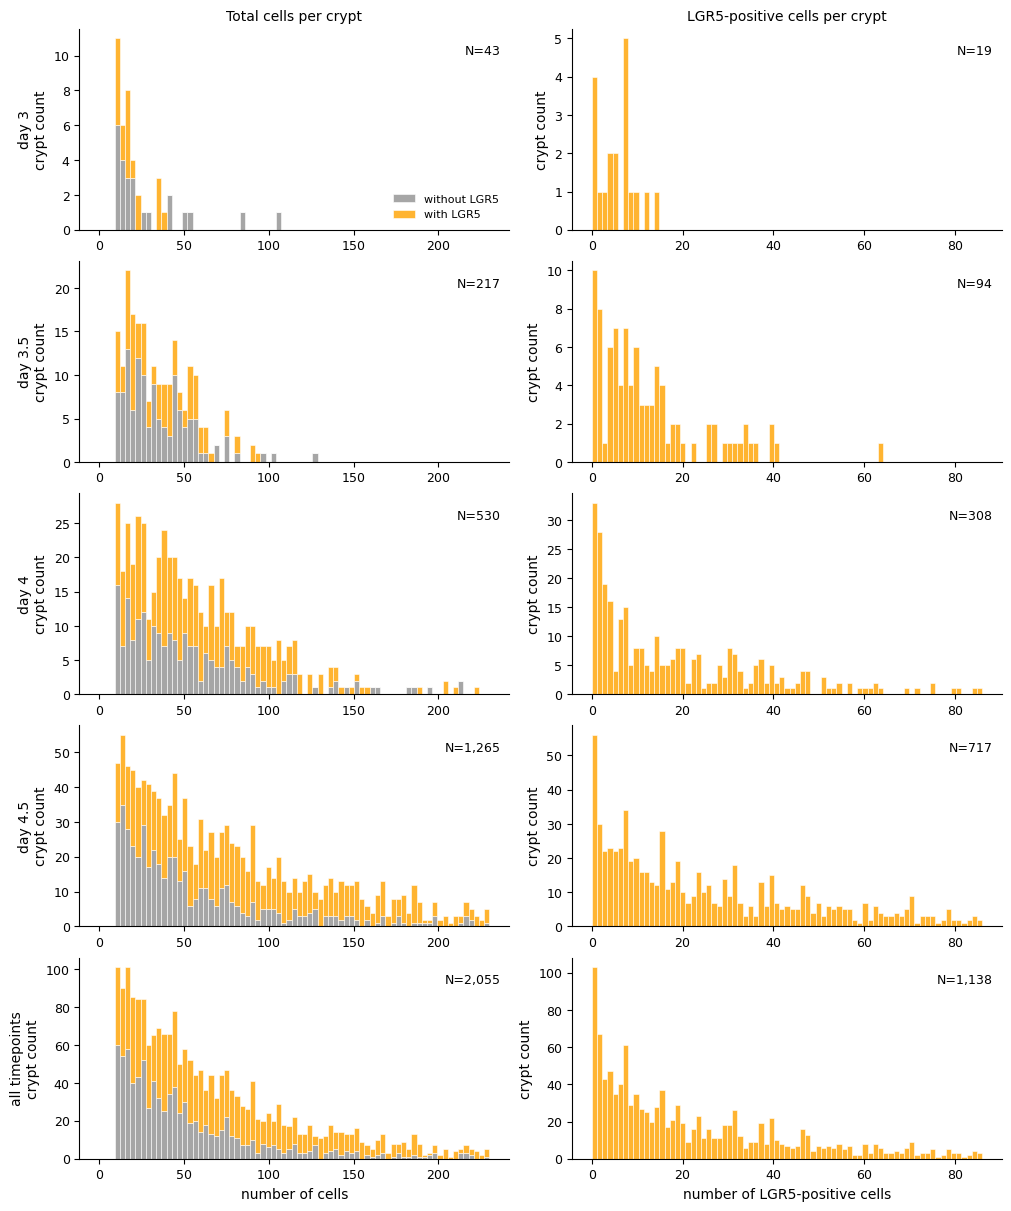

In [4]:
def shared_histogram_edges(values, n_bins=N_HISTOGRAM_BINS):
    values = pd.Series(values).dropna().to_numpy(dtype=float)
    if values.size == 0:
        return np.array([-0.5, 0.5])
    lower = min(0.0, float(np.min(values)))
    upper = float(np.max(values))
    if upper <= lower:
        return np.array([lower - 0.5, upper + 0.5])
    return np.linspace(lower, upper + 1e-9, int(n_bins) + 1)


if not 0 <= EXCLUDE_LARGEST_CRYPT_FRACTION < 1:
    raise ValueError('EXCLUDE_LARGEST_CRYPT_FRACTION must be in [0, 1).')

n_excluded = int(np.ceil(len(crypt_sizes) * EXCLUDE_LARGEST_CRYPT_FRACTION))
plot_crypt_sizes = crypt_sizes.sort_values('n_cells', kind='stable').copy()
if n_excluded > 0:
    plot_crypt_sizes = plot_crypt_sizes.iloc[:-n_excluded].copy()
print(
    f'Plotting {len(plot_crypt_sizes):,} crypts after excluding the '
    f'{n_excluded:,} largest crypts ({100 * EXCLUDE_LARGEST_CRYPT_FRACTION:g}%).'
)

if not 0 <= EXCLUDE_LARGEST_LGR5_FRACTION < 1:
    raise ValueError('EXCLUDE_LARGEST_LGR5_FRACTION must be in [0, 1).')

plot_lgr5_sizes = plot_crypt_sizes.loc[plot_crypt_sizes['n_lgr5_positive'] > 0].copy()
n_lgr5_excluded = int(np.ceil(len(plot_lgr5_sizes) * EXCLUDE_LARGEST_LGR5_FRACTION))
plot_lgr5_sizes = plot_lgr5_sizes.sort_values('n_lgr5_positive', kind='stable')
if n_lgr5_excluded > 0:
    plot_lgr5_sizes = plot_lgr5_sizes.iloc[:-n_lgr5_excluded].copy()
print(
    f'Plotting {len(plot_lgr5_sizes):,} LGR5-positive crypts in the right column after excluding the '
    f'{n_lgr5_excluded:,} largest LGR5 counts ({100 * EXCLUDE_LARGEST_LGR5_FRACTION:g}%).'
)

timepoints = sorted(plot_crypt_sizes['timepoint'].dropna().unique(), key=timepoint_sort_key)
groups = [
    (tp, display_timepoint(tp), plot_crypt_sizes.loc[plot_crypt_sizes['timepoint'] == tp])
    for tp in timepoints
]
groups.append((None, 'all timepoints', plot_crypt_sizes))

cell_edges = shared_histogram_edges(plot_crypt_sizes['n_cells'])
lgr5_edges = shared_histogram_edges(plot_lgr5_sizes['n_lgr5_positive'])

fig, axes = plt.subplots(
    nrows=len(groups),
    ncols=2,
    figsize=(10, max(2.4 * len(groups), 3.5)),
    squeeze=False,
    constrained_layout=True,
)

for row, (timepoint, group_label, group_df) in enumerate(groups):
    without_lgr5 = group_df.loc[group_df['n_lgr5_positive'] <= 0, 'n_cells'].dropna()
    with_lgr5 = group_df.loc[group_df['n_lgr5_positive'] > 0, 'n_cells'].dropna()
    axes[row, 0].hist(
        [without_lgr5, with_lgr5],
        bins=cell_edges,
        stacked=True,
        color=['#A6A6A6', '#FFB431'],
        label=['without LGR5', 'with LGR5'],
        edgecolor='white',
        linewidth=0.4,
    )
    lgr5_group_df = (
        plot_lgr5_sizes
        if timepoint is None
        else plot_lgr5_sizes.loc[plot_lgr5_sizes['timepoint'] == timepoint]
    )
    axes[row, 1].hist(
        lgr5_group_df['n_lgr5_positive'].dropna(),
        bins=lgr5_edges,
        color='#FFB431',
        edgecolor='white',
        linewidth=0.4,
    )

    axes[row, 0].set_ylabel(f'{group_label}\ncrypt count')
    axes[row, 0].text(
        0.98, 0.92, f'N={len(group_df):,}',
        transform=axes[row, 0].transAxes, ha='right', va='top', fontsize=9,
    )
    axes[row, 1].text(
        0.98, 0.92, f'N={len(lgr5_group_df):,}',
        transform=axes[row, 1].transAxes, ha='right', va='top', fontsize=9,
    )

axes[0, 0].set_title('Total cells per crypt')
axes[0, 1].set_title('LGR5-positive cells per crypt')
axes[0, 0].legend(frameon=False, fontsize=8)
axes[-1, 0].set_xlabel('number of cells')
axes[-1, 1].set_xlabel('number of LGR5-positive cells')
for ax in axes[:, 1]:
    ax.set_ylabel('crypt count')

plt.show()

## Within-organoid heterogeneity

For each organoid with at least two crypts, this section computes the sample standard deviation divided by the mean (coefficient of variation). It also computes ratios and absolute differences for every unordered pair of crypts in that organoid. Ratios place the larger count in the numerator. LGR5 ratios use a pseudocount of 1 so pairs containing zero LGR5-positive cells remain finite; LGR5 coefficients of variation are undefined and omitted when the organoid mean is zero. A second set of measurements is calculated after removing every crypt without LGR5 and retaining organoids with at least two LGR5-containing crypts. Pairwise histograms count crypt pairs, so organoids with more crypts contribute more pairs. All calculations use the complete, untrimmed `crypt_sizes` table.

In [5]:
from itertools import combinations

PAIRWISE_RATIO_PSEUDOCOUNT_LGR5 = 1.0
ORGANOID_KEYS = ['dataset', 'timepoint', 'label_uid']


def sample_cv(values):
    values = pd.Series(values).dropna().to_numpy(dtype=float)
    if values.size < 2:
        return np.nan
    mean = float(np.mean(values))
    if mean <= 0:
        return np.nan
    return float(np.std(values, ddof=1) / mean)


organoid_rows = []
pairwise_rows = []
for group_key, group_df in crypt_sizes.groupby(ORGANOID_KEYS, sort=False):
    group_df = group_df.sort_values('crypt_number')
    if len(group_df) < 2:
        continue

    dataset, timepoint, label_uid = group_key
    n_crypts = int(len(group_df))
    total_counts = group_df['n_cells'].to_numpy(dtype=float)
    lgr5_counts = group_df['n_lgr5_positive'].to_numpy(dtype=float)
    organoid_rows.append({
        'dataset': dataset,
        'timepoint': timepoint,
        'label_uid': label_uid,
        'n_crypts': n_crypts,
        'cv_total_cells': sample_cv(total_counts),
        'cv_lgr5_cells': sample_cv(lgr5_counts),
    })

    for pair_number, (i, j) in enumerate(combinations(range(n_crypts), 2)):
        total_small, total_large = sorted((total_counts[i], total_counts[j]))
        lgr5_small, lgr5_large = sorted((lgr5_counts[i], lgr5_counts[j]))
        pairwise_rows.append({
            'dataset': dataset,
            'timepoint': timepoint,
            'label_uid': label_uid,
            'n_crypts': n_crypts,
            'pair_number': pair_number,
            'ratio_total_cells': total_large / total_small if total_small > 0 else np.nan,
            'ratio_lgr5_cells': (lgr5_large + PAIRWISE_RATIO_PSEUDOCOUNT_LGR5) / (lgr5_small + PAIRWISE_RATIO_PSEUDOCOUNT_LGR5),
            'difference_total_cells': total_large - total_small,
            'difference_lgr5_cells': lgr5_large - lgr5_small,
        })

organoid_lgr5_positive_rows = []
pairwise_lgr5_positive_rows = []
for group_key, group_df in crypt_sizes.groupby(ORGANOID_KEYS, sort=False):
    group_df = group_df.loc[group_df['n_lgr5_positive'] > 0].sort_values('crypt_number')
    if len(group_df) < 2:
        continue

    dataset, timepoint, label_uid = group_key
    n_crypts = int(len(group_df))
    lgr5_counts = group_df['n_lgr5_positive'].to_numpy(dtype=float)
    organoid_lgr5_positive_rows.append({
        'dataset': dataset,
        'timepoint': timepoint,
        'label_uid': label_uid,
        'n_crypts': n_crypts,
        'cv_lgr5_positive_crypts': sample_cv(lgr5_counts),
    })

    for pair_number, (i, j) in enumerate(combinations(range(n_crypts), 2)):
        lgr5_small, lgr5_large = sorted((lgr5_counts[i], lgr5_counts[j]))
        pairwise_lgr5_positive_rows.append({
            'dataset': dataset,
            'timepoint': timepoint,
            'label_uid': label_uid,
            'n_crypts': n_crypts,
            'pair_number': pair_number,
            'ratio_lgr5_positive_crypts': lgr5_large / lgr5_small,
            'difference_lgr5_positive_crypts': lgr5_large - lgr5_small,
        })

organoid_heterogeneity = pd.DataFrame(organoid_rows)
pairwise_heterogeneity = pd.DataFrame(pairwise_rows)
organoid_lgr5_positive_heterogeneity = pd.DataFrame(organoid_lgr5_positive_rows)
pairwise_lgr5_positive_heterogeneity = pd.DataFrame(pairwise_lgr5_positive_rows)
crypt_count_categories = sorted(set(organoid_heterogeneity['n_crypts']).union(organoid_lgr5_positive_heterogeneity['n_crypts']))
heterogeneity_timepoints = sorted(
    organoid_heterogeneity['timepoint'].dropna().unique(),
    key=timepoint_sort_key,
)
row_groups = [(tp, display_timepoint(tp)) for tp in heterogeneity_timepoints]
row_groups.append((None, 'all timepoints'))

print(f'Organoids with 2+ crypts: {len(organoid_heterogeneity):,}')
print(f'Unordered crypt pairs: {len(pairwise_heterogeneity):,}')
print(f'All-zero-LGR5 organoids omitted from LGR5 CV: {organoid_heterogeneity["cv_lgr5_cells"].isna().sum():,}')
print(f'Organoids with 2+ LGR5-containing crypts: {len(organoid_lgr5_positive_heterogeneity):,}')
print(f'Unordered pairs of LGR5-containing crypts: {len(pairwise_lgr5_positive_heterogeneity):,}')
display(organoid_heterogeneity.head())
display(pairwise_heterogeneity.head())
display(organoid_lgr5_positive_heterogeneity.head())
display(pairwise_lgr5_positive_heterogeneity.head())

Organoids with 2+ crypts: 796
Unordered crypt pairs: 1,452
All-zero-LGR5 organoids omitted from LGR5 CV: 110
Organoids with 2+ LGR5-containing crypts: 364
Unordered pairs of LGR5-containing crypts: 545


,dataset,timepoint,label_uid,n_crypts,cv_total_cells,cv_lgr5_cells
0,20250929,day3,day3_A01_45,2,1.148293,NaN
1,20250929,day3,day3_A02_117,2,0.036262,1.414214
2,20250929,day3,day3_A02_99,2,0.050508,NaN
3,20250929,day3,day3_A03_1,2,0.526864,0.282843
4,20250929,day3,day3_A03_50,3,0.694622,0.916515


,dataset,timepoint,label_uid,n_crypts,pair_number,ratio_total_cells,ratio_lgr5_cells,difference_total_cells,difference_lgr5_cells
0,20250929,day3,day3_A01_45,2,0,9.636364,1.000000,95.0,0.0
1,20250929,day3,day3_A02_117,2,0,1.052632,15.000000,1.0,14.0
2,20250929,day3,day3_A02_99,2,0,1.074074,1.000000,2.0,0.0
3,20250929,day3,day3_A03_1,2,0,2.187500,1.444444,19.0,4.0
4,20250929,day3,day3_A03_50,3,0,2.769231,1.333333,23.0,1.0


,dataset,timepoint,label_uid,n_crypts,cv_lgr5_positive_crypts
0,20250929,day3,day3_A03_1,2,0.282843
1,20250929,day3,day3_A03_50,2,0.282843
2,20250929,day3,day3_A06_83,2,1.099944
3,20250929,day3,day3_B02_56,2,0.326357
4,20250929,day3p5,day3p5_A01_38,2,0.942809


,dataset,timepoint,label_uid,n_crypts,pair_number,ratio_lgr5_positive_crypts,difference_lgr5_positive_crypts
0,20250929,day3,day3_A03_1,2,0,1.5,4.0
1,20250929,day3,day3_A03_50,2,0,1.5,1.0
2,20250929,day3,day3_A06_83,2,0,8.0,7.0
3,20250929,day3,day3_B02_56,2,0,1.6,3.0
4,20250929,day3p5,day3p5_A01_38,2,0,5.0,4.0


## Heterogeneity distributions by crypt count

Each metric is shown in a separate figure with one row per timepoint and a combined bottom row. The first column uses total cell counts, the second uses LGR5-positive cell counts across all crypts, and the third first removes crypts without LGR5 and then calculates the metric from the remaining LGR5-positive cell counts. Histogram colors indicate the number of crypts used in the calculation. For each pairwise quantity, the highest 5% of values are excluded globally and separately for each column; the underlying pairwise tables remain complete.

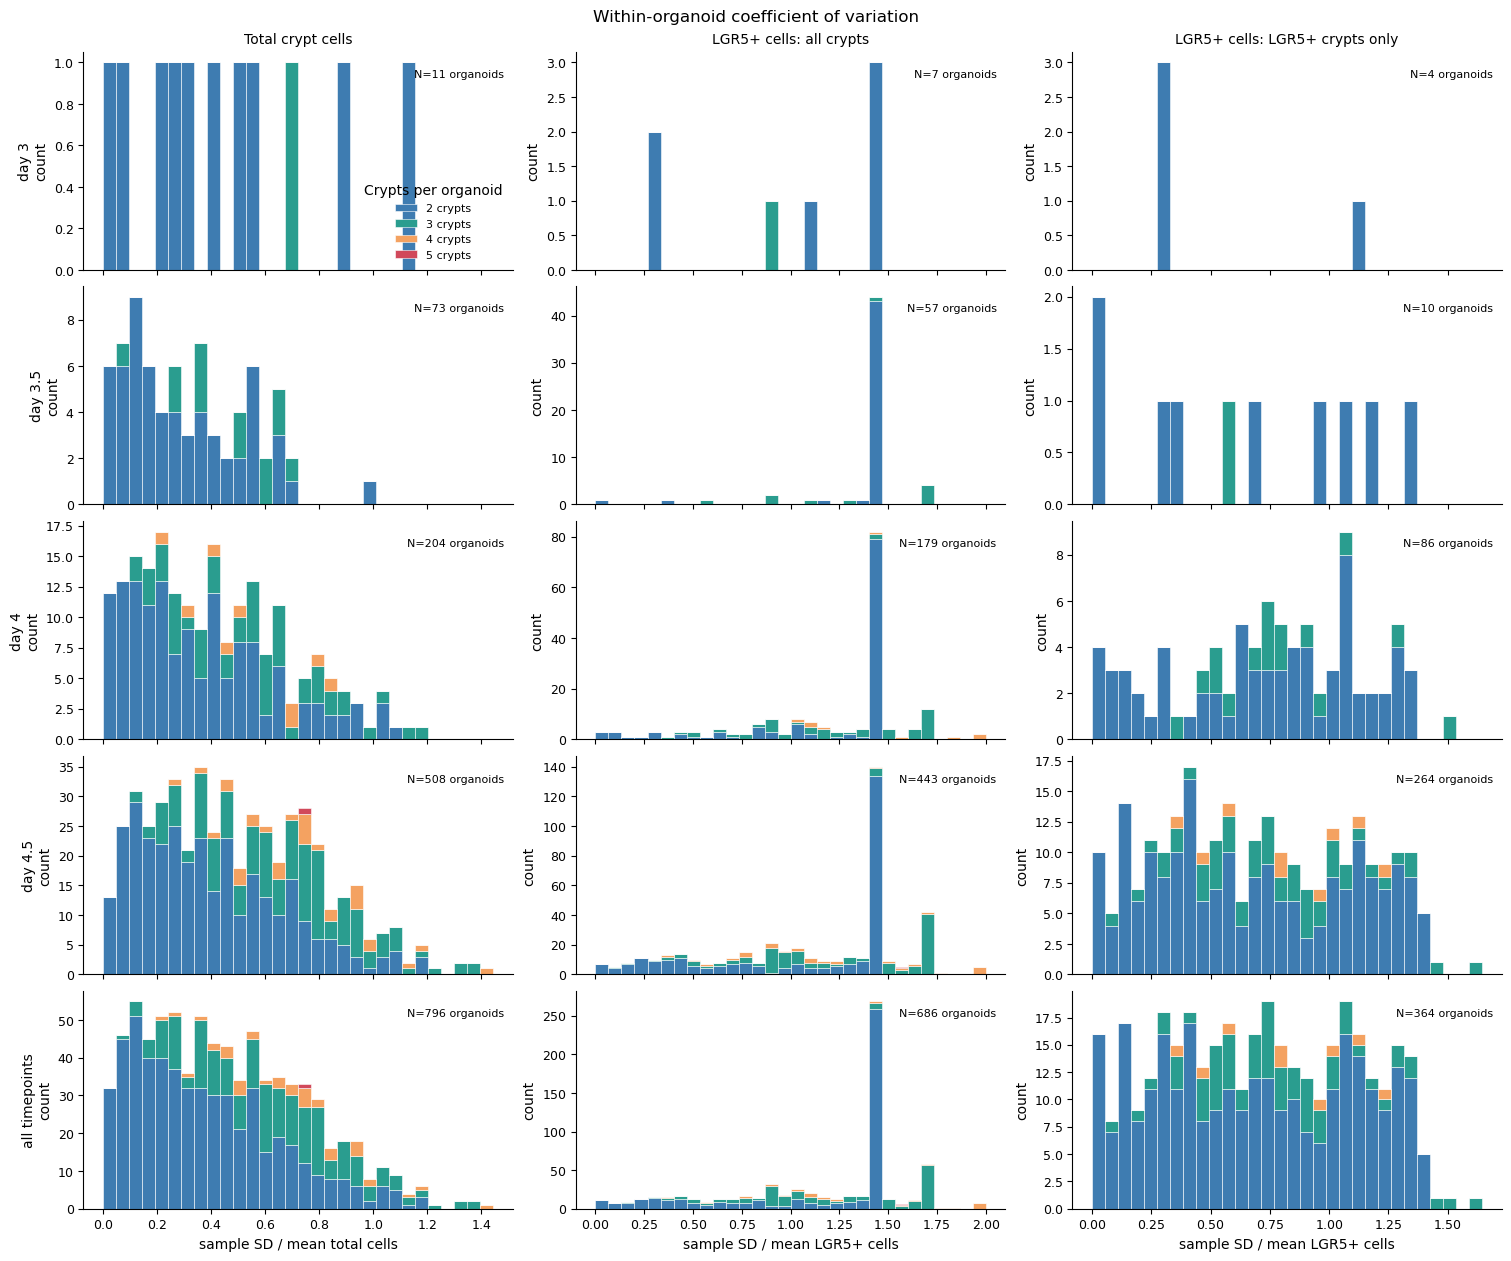

ratio_total_cells: excluded 73 highest values (5%); plotting 1,379.
ratio_lgr5_cells: excluded 73 highest values (5%); plotting 1,379.
ratio_lgr5_positive_crypts: excluded 28 highest values (5%); plotting 517.


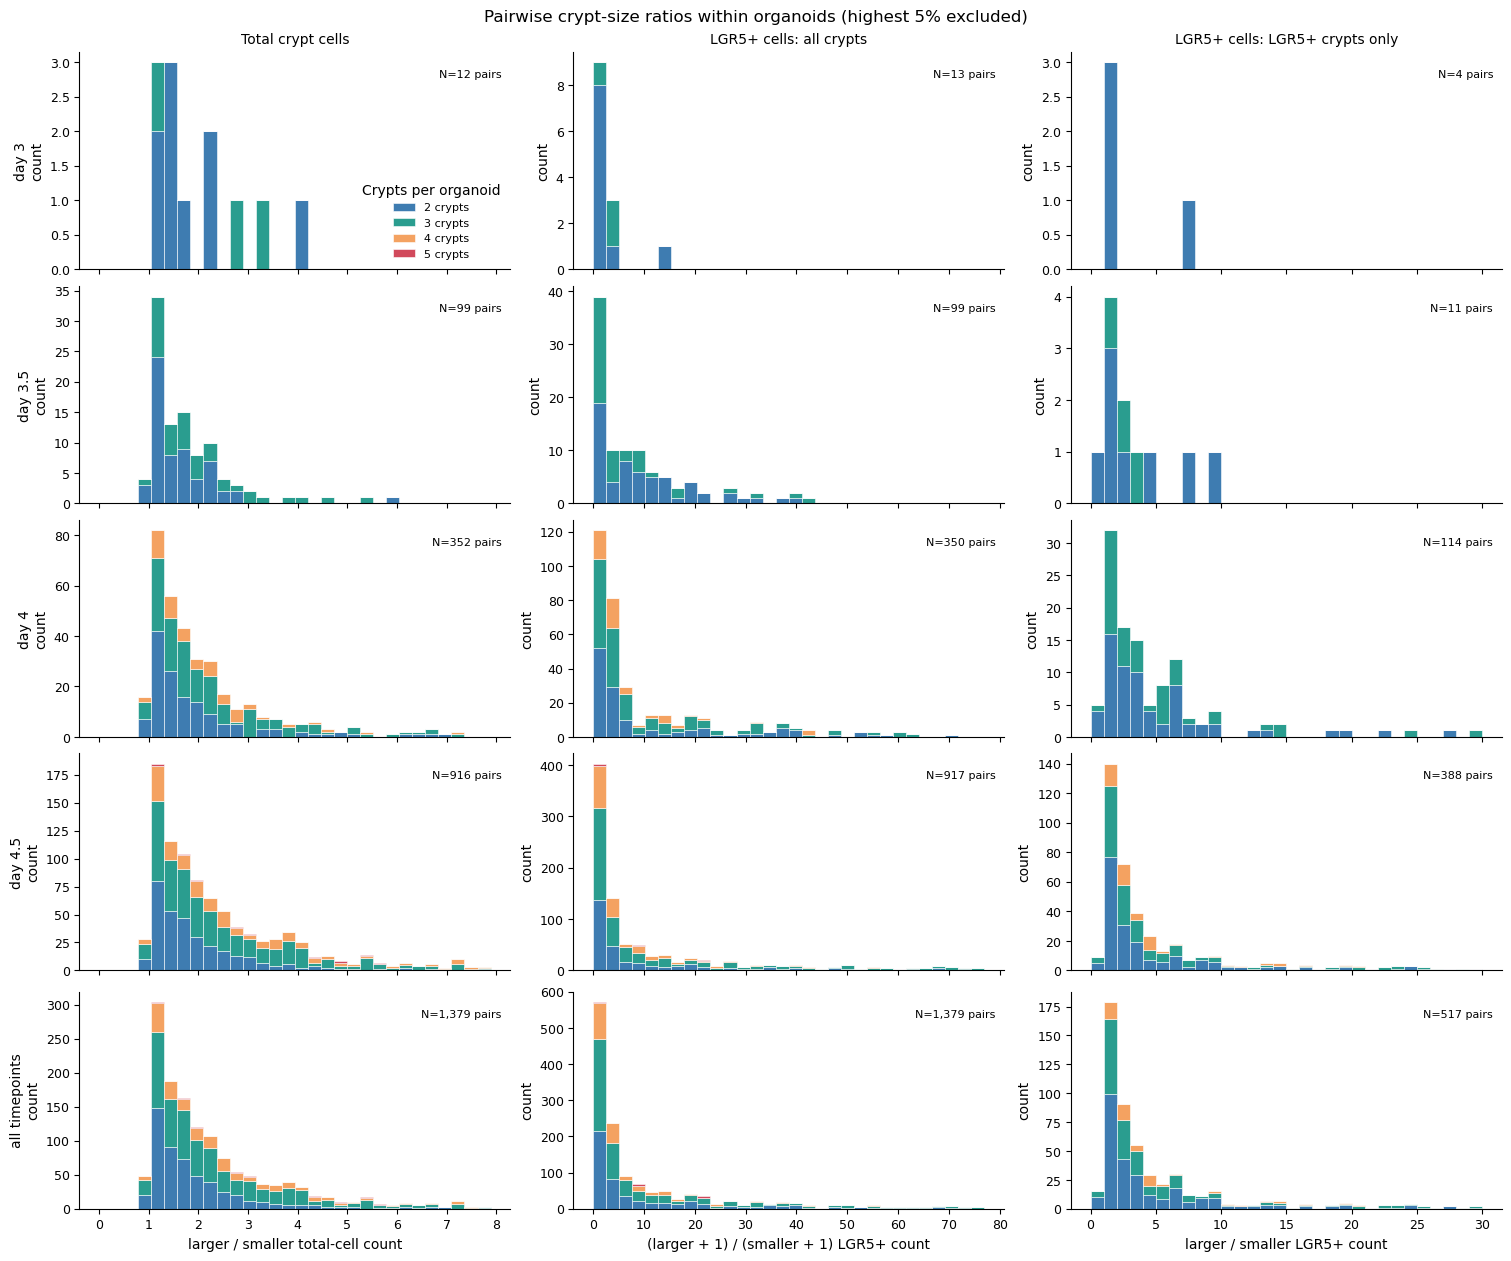

difference_total_cells: excluded 73 highest values (5%); plotting 1,379.
difference_lgr5_cells: excluded 73 highest values (5%); plotting 1,379.
difference_lgr5_positive_crypts: excluded 28 highest values (5%); plotting 517.


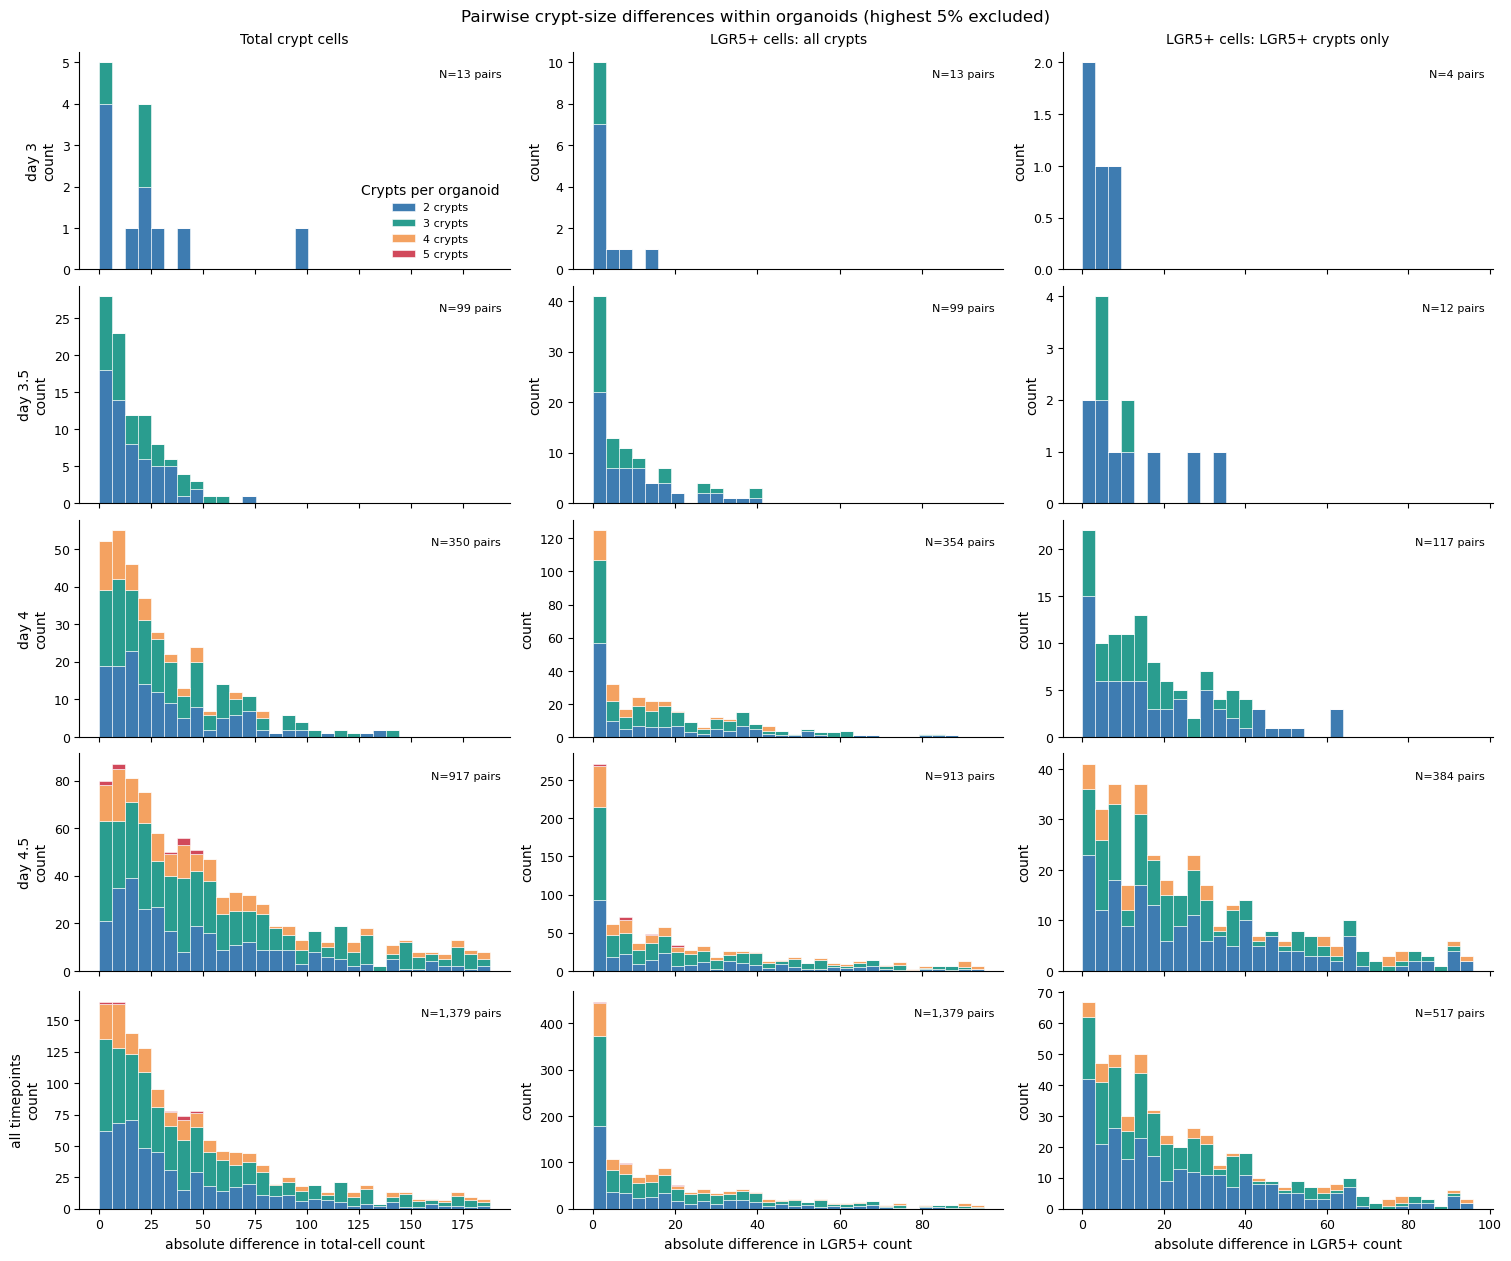

In [6]:
N_HETEROGENEITY_HISTOGRAM_BINS = 30

crypt_count_colors = {
    2: '#3E7CB1',
    3: '#2A9D8F',
    4: '#F4A261',
    5: '#D1495B',
}
fallback_colors = plt.cm.tab10(np.linspace(0, 1, max(len(crypt_count_categories), 1)))
colors = [
    crypt_count_colors.get(int(n_crypts), fallback_colors[i])
    for i, n_crypts in enumerate(crypt_count_categories)
]
labels = [f'{int(n_crypts)} crypts' for n_crypts in crypt_count_categories]


def metric_histogram_edges(values, n_bins=N_HETEROGENEITY_HISTOGRAM_BINS):
    values = pd.Series(values).dropna().to_numpy(dtype=float)
    if values.size == 0:
        return np.array([0.0, 1.0])
    lower = min(0.0, float(np.min(values)))
    upper = float(np.max(values))
    if upper <= lower:
        return np.array([lower - 0.5, upper + 0.5])
    return np.linspace(lower, upper + 1e-9, int(n_bins) + 1)


def plot_stacked_heterogeneity_histograms(
    data_columns,
    metric_columns,
    column_titles,
    figure_title,
    xlabels,
    observation_name,
    upper_trim_fraction=0.0,
):
    if not 0 <= upper_trim_fraction < 1:
        raise ValueError('upper_trim_fraction must be in [0, 1).')
    if not (len(data_columns) == len(metric_columns) == len(column_titles) == len(xlabels)):
        raise ValueError('Each plotted column needs one data frame, metric, title, and x-label.')

    plot_data = []
    edges = []
    for source_data, metric in zip(data_columns, metric_columns):
        metric_data = source_data.loc[source_data[metric].notna()].sort_values(metric, kind='stable').copy()
        n_trimmed = int(np.ceil(len(metric_data) * upper_trim_fraction))
        if n_trimmed > 0:
            metric_data = metric_data.iloc[:-n_trimmed].copy()
        plot_data.append(metric_data)
        edges.append(metric_histogram_edges(metric_data[metric]))
        if upper_trim_fraction > 0:
            print(
                f'{metric}: excluded {n_trimmed:,} highest values '
                f'({100 * upper_trim_fraction:g}%); plotting {len(metric_data):,}.'
            )
    fig, axes = plt.subplots(
        nrows=len(row_groups),
        ncols=len(metric_columns),
        figsize=(5 * len(metric_columns), 2.5 * len(row_groups)),
        sharex='col',
        squeeze=False,
        constrained_layout=True,
    )

    for row, (timepoint, row_label) in enumerate(row_groups):
        for col, (metric, column_title, xlabel) in enumerate(zip(metric_columns, column_titles, xlabels)):
            ax = axes[row, col]
            metric_data = plot_data[col]
            timepoint_df = (
                metric_data
                if timepoint is None
                else metric_data.loc[metric_data['timepoint'] == timepoint]
            )
            stacked_values = [
                timepoint_df.loc[timepoint_df['n_crypts'] == n_crypts, metric].dropna()
                for n_crypts in crypt_count_categories
            ]
            ax.hist(
                stacked_values,
                bins=edges[col],
                stacked=True,
                color=colors,
                label=labels,
                edgecolor='white',
                linewidth=0.4,
            )
            n_valid = int(timepoint_df[metric].notna().sum())
            ax.text(
                0.98, 0.92, f'N={n_valid:,} {observation_name}',
                transform=ax.transAxes, ha='right', va='top', fontsize=8,
            )
            if row == 0:
                ax.set_title(column_title)
            if col == 0:
                ax.set_ylabel(f'{row_label}\ncount')
            else:
                ax.set_ylabel('count')
            if row == len(row_groups) - 1:
                ax.set_xlabel(xlabel)

    axes[0, 0].legend(frameon=False, fontsize=8, title='Crypts per organoid')
    trim_suffix = f' (highest {100 * upper_trim_fraction:g}% excluded)' if upper_trim_fraction > 0 else ''
    fig.suptitle(f'{figure_title}{trim_suffix}', fontsize=12)
    plt.show()
    return fig, axes


cv_figure, cv_axes = plot_stacked_heterogeneity_histograms(
    data_columns=[
        organoid_heterogeneity,
        organoid_heterogeneity,
        organoid_lgr5_positive_heterogeneity,
    ],
    metric_columns=['cv_total_cells', 'cv_lgr5_cells', 'cv_lgr5_positive_crypts'],
    column_titles=['Total crypt cells', 'LGR5+ cells: all crypts', 'LGR5+ cells: LGR5+ crypts only'],
    figure_title='Within-organoid coefficient of variation',
    xlabels=[
        'sample SD / mean total cells',
        'sample SD / mean LGR5+ cells',
        'sample SD / mean LGR5+ cells',
    ],
    observation_name='organoids',
)

ratio_figure, ratio_axes = plot_stacked_heterogeneity_histograms(
    data_columns=[
        pairwise_heterogeneity,
        pairwise_heterogeneity,
        pairwise_lgr5_positive_heterogeneity,
    ],
    metric_columns=['ratio_total_cells', 'ratio_lgr5_cells', 'ratio_lgr5_positive_crypts'],
    column_titles=['Total crypt cells', 'LGR5+ cells: all crypts', 'LGR5+ cells: LGR5+ crypts only'],
    figure_title='Pairwise crypt-size ratios within organoids',
    xlabels=[
        'larger / smaller total-cell count',
        f'(larger + {PAIRWISE_RATIO_PSEUDOCOUNT_LGR5:g}) / (smaller + {PAIRWISE_RATIO_PSEUDOCOUNT_LGR5:g}) LGR5+ count',
        'larger / smaller LGR5+ count',
    ],
    observation_name='pairs',
    upper_trim_fraction=0.05,
)

difference_figure, difference_axes = plot_stacked_heterogeneity_histograms(
    data_columns=[
        pairwise_heterogeneity,
        pairwise_heterogeneity,
        pairwise_lgr5_positive_heterogeneity,
    ],
    metric_columns=['difference_total_cells', 'difference_lgr5_cells', 'difference_lgr5_positive_crypts'],
    column_titles=['Total crypt cells', 'LGR5+ cells: all crypts', 'LGR5+ cells: LGR5+ crypts only'],
    figure_title='Pairwise crypt-size differences within organoids',
    xlabels=[
        'absolute difference in total-cell count',
        'absolute difference in LGR5+ count',
        'absolute difference in LGR5+ count',
    ],
    observation_name='pairs',
    upper_trim_fraction=0.05,
)